# Lab2 Part1: Feetech Motor Control Using Python — Single Motor

In this lab we will use Python to control Feetech STS3215 servo motors — the same motors used in the SO-Arm 101 robot you will build later in the course. This notebook covers wiring up **one** motor and learning to control it directly.

This lab is split across three notebooks:
- **Part 1 (this notebook)** — connect one motor; position control, trajectory tracking, speed control
- **Part 2** (`Lab2 Part2 - Two Motor Control.ipynb`) — add a second motor and coordinate both simultaneously
- **Problems** (`Lab2 Problems.ipynb`) — open-ended exercises built on Parts 1 and 2

### In this part, you will 

**Task 1 — Connect the Hardware**

Set up the motor, power supply, and USB adapter.

**Task 2 — Single Motor Control**
1. Move the motor to a target angle and read back the actual position
2. Command the motor to track a sine wave trajectory and measure how closely it follows
3. Control motor speed in wheel mode

When you finish Task 2, close this notebook and open `Lab2 Part2 - Two Motor Control.ipynb`.


## Task 1: Hardware Connection

You need four components for this lab:

| Component | Purpose |
|-----------|---------|
| **Feetech STS3215 motor** (12V, C018) | The actuator — same motor used in SO-Arm 101. [Order link](https://shop.wowrobo.com/products/feetech-sts3215-servo-12v-30kg-high-torque-servo-for-so-arm100) |
| **12V / 8A power adapter** | Powers the motor. [Order link](https://www.amazon.com/IEIK-Adapter-Converter-Transformer-Computer/dp/B0839BTVBW). Others will work as long as it provide 12V and at least 8A|
| **Bus Servo Adapter** | Translates USB commands into the motor's serial protocol. [Order link](https://www.amazon.com/Waveshare-Integrates-Control-Circuit-Supports/dp/B0CTMM4LWK?th=1) |
| **USB-C cable** | Connects your laptop to the adapter. |


> ⚠️ If you damage your motor, power supply, or the Bus Servo Adapter, you are responsible for replacing it.

> **Important:** There are several versions of the STS3215 servo. The one used in this lab is the 12V version (part number: ST-3215-C018).

### Wiring steps

**Step 1 — Motor to adapter (3-pin cable)**  
Match the wire colors: Black → G (Ground), Red → V (Voltage), White → D (Data).  
Set the adapter's mode switch to **USB-SERVO (B Mode)**.

**Step 2 — USB cable**  
Plug the USB-C cable from the adapter into your laptop.

**Step 3 — Power supply**  
Connect the 12V supply to the adapter and switch it on.  
You should see **red LEDs** light up on both the adapter and the motor.

Your setup should look like this

<img src="OneMotorConnection.png" width="600">

### Find your COM port

The motor communicates through a serial (COM) port. You need to know which port your adapter is assigned to. Open a Anaconda, first activate the course environment

```
activate me416
```

Then run the port-finder tool

```
lerobot-find-port
```

You will see output like `COM3` or `COM5`. The following is an example showing `COM4`
<img src="FindPort.png" width="600">

Revise the following code to the correct COM based on your connection. 

> **Important:** If you reconnect the adapter to a different USB port on your computer, run the port-finder tool again. The adapter may be assigned a different COM port number. In this case, it is good to mark it on your laptop using a pencile so that you don't need to do this next time when you connect to the same USB port.

In [1]:
# ── Session setup — run this cell at the start of every session ──────────────
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
"""
Lab2_helpers is a helper file that contains functions for communicating 
with the robot and plotting data. 
You need to download this file from the course website 
and place it in the same folder as this notebook.
"""
from Lab2_helpers import * 

# ── !!!!Update this value to match your setup !!!! ────────────────────────────────────
PORT     = "COM4"   # from lerobot-find-port
MOTOR_ID = 1         # factory default

print("Lab2 Part1 ready.")

Lab2 Part1 ready.


---
## Task 2 — Single Motor Control


### Task 2.1 — Move the Motor to a Target Angle

We'll control the motor with four helper functions from `Lab2_helpers.py` (already imported in the session-setup cell). These same functions also work with two or more motors later in the course — you just pass more angles or IDs.

| Function | What it does |
|----------|-------------|
| `connect_motors(port, motor_id)` | Opens a connection to the motor over the USB adapter, sets position control mode, and enables torque. Returns a `bus` object. |
| `write_angles(bus, deg)` | Commands the motor to move to a target angle (degrees) and hold it there. |
| `read_angles(bus)` | Reads back the motor's current angle (degrees). |
| `disconnect_motors(bus)` | Disables torque and closes the connection, releasing the COM port. |

Internally, the motor measures position in integer steps called *ticks* (4096 ticks = one full revolution; 2048 ticks = 0°) — `write_angles` and `read_angles` handle that degrees ↔ ticks conversion for you.

> **Try it:** change `TARGET_DEG` to different values such as 30, 90, or −45 and re-run the cell. Notice that the measured position always matches the target closely once the motor has had time to settle.

> **Curious what happens inside these functions?** Open `Lab2_helpers.py` to see the raw `FeetechMotorsBus` commands they wrap.

In [2]:
TARGET_DEG = 0.0  # target angle in degrees; valid range is -180 to +180

bus = connect_motors(PORT, MOTOR_ID)   # open the connection, set position mode, enable torque

write_angles(bus, TARGET_DEG)          # command the motor to move
time.sleep(1.8)                        # give it time to arrive
measured_deg = read_angles(bus)        # read back where it actually ended up

print(f"Target  : {TARGET_DEG:.1f}°")
print(f"Measured: {measured_deg:.1f}°")

disconnect_motors(bus)                 # release the COM port

Target  : 0.0°
Measured: 0.1°
Motor disconnected.


> **Try it:** To see the angle change more obviously, put one of the metal disk horn in the motor package onto motor shaft. You can use your pen to draw a line on this horn.

### Task 2.2 — Follow a Sine Wave Trajectory

So far the motor moved to a fixed angle and stopped. Now we will command it to continuously track a moving target. Instead of sending one position command, we send a new position command every 20 ms, where each new target follows a sine wave:

$$\theta_{\text{ref}}(t) = A \sin(2\pi f t) \quad [\text{degrees}]$$

- **A** = amplitude — how far the motor swings to each side (degrees)
- **f** = frequency — how many complete back-and-forth cycles per second (Hz)

The code records both the **reference** (commanded) and **actual** (measured) angle 50 times per second. After the run finishes, the next cell plots the two signals and computes the tracking error.

> **Try it:** After running once at `SINE_FREQUENCY_HZ = 0.5`, change the frequency to `1.0` or `2.0` and run again. Think about what will happen at higher frequencies and verify it on the motor. Why this happens?

In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# PORT and MOTOR_ID were set in Task 2.1. Re-run that cell if you get a connection error.

# ── Parameters — try changing these ──────────────────────────────────────────
SINE_AMPLITUDE_DEG = 45.0   # peak swing: motor moves ±45° from centre
SINE_FREQUENCY_HZ  = 0.5    # cycles per second; try 0.2, 0.5, 1.0, 2.0
SINE_DURATION_SEC  = 6.0    # how long to run (seconds)
SINE_SAMPLE_HZ     = 50     # *target* position readings per second -- see note below

print("Sine wave parameters:")
print(f"  Amplitude : ±{SINE_AMPLITUDE_DEG}°")
print(f"  Frequency : {SINE_FREQUENCY_HZ} Hz  (period = {1/SINE_FREQUENCY_HZ:.1f} s)")
print(f"  Duration  : {SINE_DURATION_SEC} s")

# Lists, not pre-allocated arrays: each write+read round trip over the serial
# bus takes longer than 1/SINE_SAMPLE_HZ, so the achieved rate ends up below
# SINE_SAMPLE_HZ and the number of samples needed to fill SINE_DURATION_SEC
# isn't known ahead of time. Stopping on elapsed time (instead of a fixed
# sample count) is what makes SINE_DURATION_SEC mean what it says.
dt = 1.0 / SINE_SAMPLE_HZ
t_list, ref_list, act_list = [], [], []

bus = connect_motors(PORT, MOTOR_ID)
print("\nRunning — do not interrupt until 'Done' appears...")

t_start = time.time() # record the start time
while True:
    tick  = time.time() # record the time at the start of this sample
    t_now = tick - t_start # compute the elapsed time since the start of the sine wave
    if t_now >= SINE_DURATION_SEC:
        break

    # Compute the reference angle for this instant
    ref_deg = SINE_AMPLITUDE_DEG * np.sin(2 * np.pi * SINE_FREQUENCY_HZ * t_now)

    write_angles(bus, ref_deg)   # send the command
    act_deg = read_angles(bus)   # read back where the motor actually is

    # Store the sample
    t_list.append(t_now)
    ref_list.append(ref_deg)
    act_list.append(act_deg)

    # Sleep for whatever is left of this period, so we hold as close to
    # SINE_SAMPLE_HZ as the hardware round trip allows
    elapsed = time.time() - tick
    if elapsed < dt:
        time.sleep(dt - elapsed)

t_sine   = np.array(t_list)
ref_sine = np.array(ref_list)
act_sine = np.array(act_list)

# Return to 0° and clean up
write_angles(bus, 0.0)
time.sleep(1.5)
disconnect_motors(bus)

achieved_hz = len(t_sine) / t_sine[-1] if len(t_sine) > 1 else float("nan")
print(f"Done. Recorded {len(t_sine)} samples over {t_sine[-1]:.2f} s "
      f"(~{achieved_hz:.0f} Hz achieved vs. {SINE_SAMPLE_HZ} Hz requested -- "
      "write+read round trips over the bus are the limiting factor).")
print("Run the next cell to plot the results.")

Sine wave parameters:
  Amplitude : ±45.0°
  Frequency : 0.5 Hz  (period = 2.0 s)
  Duration  : 6.0 s

Running — do not interrupt until 'Done' appears...
Motor disconnected.
Done. Recorded 114 samples over 5.96 s (~19 Hz achieved vs. 50 Hz requested -- write+read round trips over the bus are the limiting factor).
Run the next cell to plot the results.


The plot below shows two panels:

- **Top:** reference (blue dashed) vs. actual (red solid) angle. Good tracking means the two lines overlap. At higher frequencies you will see the red line lag behind and shrink in amplitude.
- **Bottom:** tracking error (actual − reference). The RMS value summarises the average error over the entire run.

A smaller RMS error and tighter overlap in the top panel means the motor is tracking well.

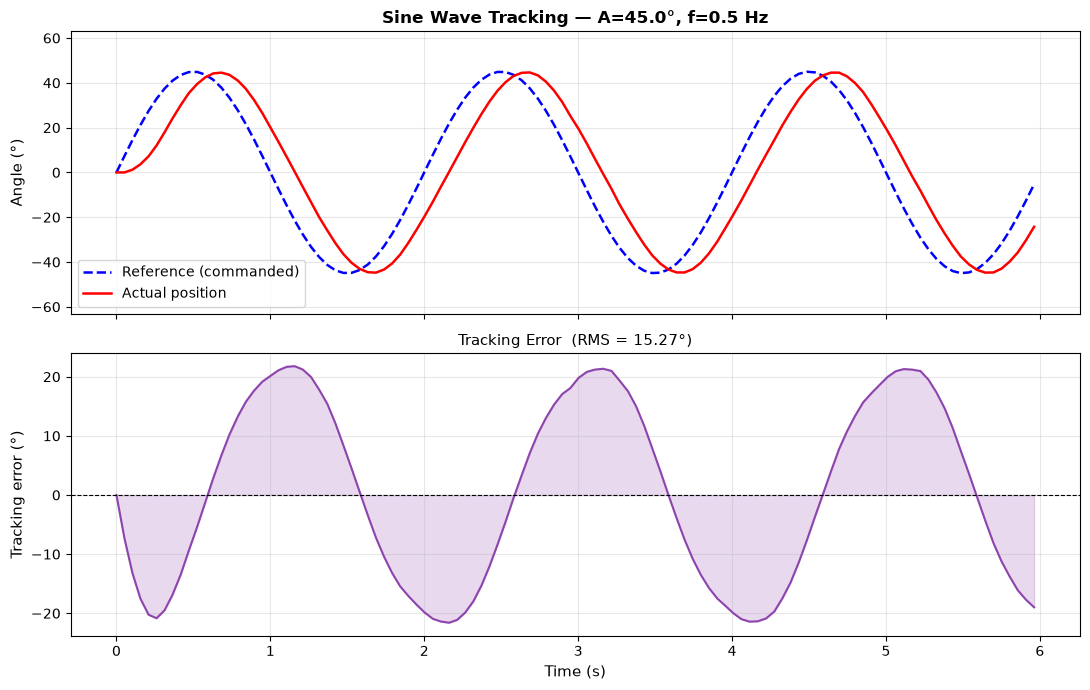

RMS tracking error: 15.27°
Plot saved as sine_tracking_single.png


In [4]:
# Plot the sine wave tracking results.
# Top panel: reference vs. actual angle.
# Bottom panel: tracking error (actual − reference) with RMS value.

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.plot(t_sine, ref_sine, "b--", linewidth=1.8, label="Reference (commanded)")
ax1.plot(t_sine, act_sine, "r-",  linewidth=1.8, label="Actual position")
ax1.set_ylabel("Angle (°)", fontsize=11)
ax1.set_title(f"Sine Wave Tracking — A={SINE_AMPLITUDE_DEG}°, f={SINE_FREQUENCY_HZ} Hz",
              fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-SINE_AMPLITUDE_DEG * 1.4, SINE_AMPLITUDE_DEG * 1.4)

error = act_sine - ref_sine
rms_err = np.sqrt(np.mean(error**2))

ax2.plot(t_sine, error, color="#8e44ad", linewidth=1.5)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.fill_between(t_sine, error, 0, alpha=0.2, color="#8e44ad")
ax2.set_ylabel("Tracking error (°)", fontsize=11)
ax2.set_xlabel("Time (s)", fontsize=11)
ax2.set_title(f"Tracking Error  (RMS = {rms_err:.2f}°)", fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("sine_tracking_single.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"RMS tracking error: {rms_err:.2f}°")
print("Plot saved as sine_tracking_single.png")

### Task 2.3 — Speed Control (Wheel Mode)

So far we have used **position control**: you specify a target angle and the motor drives itself there. The STS3215 also supports **speed control** (also called *wheel mode*), where you specify a rotational speed instead of a target angle. The motor spins continuously at that speed until you send a new command.

| | Position control | Speed control |
|--|--|--|
| **You specify** | Target angle (°) | Rotational speed |
| **Motor does** | Moves to target and holds | Spins continuously |
| **Stops when** | It reaches the target | You command speed = 0 |

Two more helper functions from `Lab2_helpers.py` handle wheel mode, mirroring `connect_motors`/`write_angles` from Task 2.1:

| Function | What it does |
|----------|-------------|
| `connect_motors_velocity(port, motor_id)` | Opens a connection to the motor and switches it to velocity (wheel) mode instead of position mode. Returns a `bus` object. |
| `write_speeds(bus, speed)` | Commands the motor to spin continuously at `speed`. |

**Speed values for STS3215:**
- `0` → stop
- Positive values (e.g. `300`, `600`, `1000`) → rotate in one direction
- Negative values (e.g. `-300`, `-600`, `-1000`) → rotate in the opposite direction
- `±1000` ≈ maximum speed (~50 RPM at 12V)

> ⚠️ In speed mode the motor spins without a position limit. Keep the motor shaft free of any load or attachment when running this task.

In [5]:
# ── Change these values to experiment ────────────────────────────────────────
SPEED   = -300    # rotation speed: positive = one direction, negative = opposite
                  # try 300, 600, 1000, -300, -600, -1000  (range: -1000 to +1000)
RUN_SEC = 3.0     # how many seconds to spin at that speed

bus = connect_motors_velocity(PORT, MOTOR_ID)   # connect and switch to velocity (wheel) mode

write_speeds(bus, SPEED)                        # start spinning
print(f"Spinning at speed {SPEED:+d} for {RUN_SEC} s ...")
time.sleep(RUN_SEC)

write_speeds(bus, 0)                            # stop
disconnect_motors(bus)                          # release the COM port
print("Done.")

Spinning at speed -300 for 3.0 s ...
Motor disconnected.
Done.


---
## Next Steps

You've moved a single motor to a target angle, tracked a sine wave trajectory, and driven it in speed (wheel) mode.

Continue to **`Lab2 Part 2 - Two Motor Control.ipynb`** to assign a second motor its own ID and control both motors together.
